<a href="https://www.kaggle.com/code/aamir28/llm-benchmark-tracker-2026?scriptVersionId=329419890" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#0a0a12;border-radius:16px;font-family:'Segoe UI',sans-serif;overflow:hidden;border:1px solid #27272f;">

  <div style="background:linear-gradient(135deg,#1e1b4b 0%,#312e81 50%,#1e1b4b 100%);padding:30px 40px;">
    <div style="display:flex;justify-content:space-between;align-items:flex-start;">
      <div>
        <div style="font-size:0.65rem;letter-spacing:4px;color:#a5b4fc;font-weight:700;margin-bottom:8px;">LLM BENCHMARK TRACKER · 2026 EDITION</div>
        <h1 style="margin:0;font-size:2rem;font-weight:900;color:#fff;">🏆 The State of Large Language Models</h1>
        <p style="margin:8px 0 0;color:#c7d2fe;font-size:0.85rem;max-width:560px;line-height:1.7;">61 models from 21 providers, benchmarked across 9 evaluation suites — MMLU, HumanEval, MATH, GPQA, GSM8K, HellaSwag, ARC-Challenge, TruthfulQA, MBPP — plus Chatbot Arena ELO and per-token pricing.</p>
      </div>
      <div style="background:rgba(255,255,255,0.08);border-radius:10px;padding:14px 18px;text-align:center;min-width:90px;">
        <div style="font-size:2.2rem;">🤖</div>
        <div style="font-size:0.62rem;color:#a5b4fc;margin-top:4px;">n=61</div>
      </div>
    </div>
  </div>

  <!-- Leaderboard top 5 strip -->
  <div style="background:#13111f;padding:16px 40px;border-bottom:1px solid #27272f;">
    <div style="font-size:0.62rem;letter-spacing:2px;color:#818cf8;margin-bottom:10px;">🥇 TOP 5 — ARENA ELO LEADERBOARD</div>
    <div style="display:grid;grid-template-columns:repeat(5,1fr);gap:10px;">
      <div style="background:#1a1730;border-radius:8px;padding:10px 12px;border-left:3px solid #fbbf24;">
        <div style="font-size:0.95rem;font-weight:700;color:#fde68a;">o3</div>
        <div style="font-size:0.68rem;color:#94a3b8;">OpenAI · ELO 1410</div></div>
      <div style="background:#1a1730;border-radius:8px;padding:10px 12px;border-left:3px solid #d1d5db;">
        <div style="font-size:0.95rem;font-weight:700;color:#e5e7eb;">DeepSeek-R2</div>
        <div style="font-size:0.68rem;color:#94a3b8;">DeepSeek · ELO 1405</div></div>
      <div style="background:#1a1730;border-radius:8px;padding:10px 12px;border-left:3px solid #fb923c;">
        <div style="font-size:0.95rem;font-weight:700;color:#fed7aa;">Gemini 2.5 Pro</div>
        <div style="font-size:0.68rem;color:#94a3b8;">Google · ELO 1399</div></div>
      <div style="background:#1a1730;border-radius:8px;padding:10px 12px;border-left:3px solid #818cf8;">
        <div style="font-size:0.95rem;font-weight:700;color:#c7d2fe;">Claude Opus 4</div>
        <div style="font-size:0.68rem;color:#94a3b8;">Anthropic · ELO 1390</div></div>
      <div style="background:#1a1730;border-radius:8px;padding:10px 12px;border-left:3px solid #818cf8;">
        <div style="font-size:0.95rem;font-weight:700;color:#c7d2fe;">Grok-3</div>
        <div style="font-size:0.68rem;color:#94a3b8;">xAI · ELO 1385</div></div>
    </div>
  </div>

  <div style="padding:22px 40px;display:grid;grid-template-columns:repeat(5,1fr);gap:12px;">
    <div style="text-align:center;"><div style="font-size:1.3rem;font-weight:800;color:#818cf8;">21</div><div style="font-size:0.65rem;color:#64748b;">PROVIDERS</div></div>
    <div style="text-align:center;"><div style="font-size:1.3rem;font-weight:800;color:#34d399;">37</div><div style="font-size:0.65rem;color:#64748b;">OPEN-WEIGHT</div></div>
    <div style="text-align:center;"><div style="font-size:1.3rem;font-weight:800;color:#fbbf24;">13</div><div style="font-size:0.65rem;color:#64748b;">REASONING MODELS</div></div>
    <div style="text-align:center;"><div style="font-size:1.3rem;font-weight:800;color:#f472b6;">$75</div><div style="font-size:0.65rem;color:#64748b;">MAX /1M IN</div></div>
    <div style="text-align:center;"><div style="font-size:1.3rem;font-weight:800;color:#60a5fa;">10M</div><div style="font-size:0.65rem;color:#64748b;">MAX CONTEXT (TOKENS)</div></div>
  </div>

  <div style="background:#13111f;padding:10px 40px;border-top:1px solid #27272f;font-size:0.68rem;color:#3f3f5c;">Author: Muhammad Aamir · LLM Benchmark Tracker 2026 · Kaggle Notebook</div>
</div>


## 🏆 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Provider Landscape](#2)
3. [Feature Engineering](#3)
4. [Benchmark Leaderboards](#4)
5. [Reasoning Models — The Math Gap](#5)
6. [Open-Weight vs Proprietary](#6)
7. [Cost vs Performance — Finding the Value Frontier](#7)
8. [Context Window & Capability Trends](#8)
9. [Benchmark Correlation Structure](#9)
10. [Release Timeline & Provider Trajectories](#10)
11. [ML — Predicting Arena ELO from Benchmarks](#11)
12. [Key Takeaways](#12)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

BG, PANEL, GRID = '#0a0a12','#13111f','#27272f'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#94a3b8','axes.titlecolor':'#f1f0ff','axes.titlesize':13,
    'xtick.color':'#64748b','ytick.color':'#64748b','text.color':'#94a3b8',
    'grid.color':'#1a1825','grid.linewidth':0.6,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

INDIGO = '#818cf8'
GOLD   = '#fbbf24'
GREEN  = '#34d399'
PINK   = '#f472b6'
BLUE   = '#60a5fa'
RED    = '#f87171'
GRAY   = '#94a3b8'
OPEN_PAL = {'True': GREEN, 'False': INDIGO}
REASON_PAL = {'True': GOLD, 'False': GRAY}
CMAP_I = LinearSegmentedColormap.from_list('i', [BG, INDIGO, '#e0e7ff'])
CMAP_DIV = LinearSegmentedColormap.from_list('d', [RED, BG, GREEN])
print('✅  Leaderboard theme loaded. 61 models ready for benchmarking.')


✅  Leaderboard theme loaded. 61 models ready for benchmarking.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/aamir28/global-llm-benchmark-tracker/llm_benchmark_tracker_2026.csv',
                 parse_dates=['release_date'])
print(f'Shape: {df.shape}')
print(f'Providers: {df.provider.nunique()}')
df.head(8)


Shape: (61, 32)
Providers: 21


,model_name,provider,release_date,model_family,parameter_size_b,context_window_k,is_open_weight,is_multimodal,is_reasoning_model,mmlu_score,...,api_available,deployment_type,languages_supported,max_output_tokens,fine_tunable,tool_use,vision,audio,knowledge_cutoff,notes
0,GPT-4o,OpenAI,2024-05-13,GPT-4,unknown,128,False,True,False,88.7,...,True,Cloud,100+,4096,False,True,True,True,2024-04,Flagship multimodal model from OpenAI
1,GPT-4o-mini,OpenAI,2024-07-18,GPT-4,unknown,128,False,True,False,82.0,...,True,Cloud,100+,16384,False,True,True,False,2024-04,Cost-efficient small model
2,o3,OpenAI,2025-04-16,o-series,unknown,200,False,True,True,96.7,...,True,Cloud,100+,100000,False,True,True,False,2025-01,State-of-the-art reasoning model
3,o4-mini,OpenAI,2025-04-16,o-series,unknown,200,False,True,True,93.4,...,True,Cloud,100+,100000,False,True,True,False,2025-01,Efficient reasoning model
4,GPT-4.5,OpenAI,2025-02-27,GPT-4,unknown,128,False,True,False,89.1,...,True,Cloud,100+,16384,False,True,True,False,2025-01,Large-scale model optimized for EQ
5,Claude 3.5 Sonnet,Anthropic,2024-10-22,Claude-3,unknown,200,False,True,False,90.4,...,True,Cloud,80+,8192,False,True,True,False,2024-04,Top coding and analysis model
6,Claude 3.7 Sonnet,Anthropic,2025-02-24,Claude-3,unknown,200,False,True,True,93.2,...,True,Cloud,80+,128000,False,True,True,False,2025-01,Extended thinking hybrid model
7,Claude Opus 4,Anthropic,2025-05-22,Claude-4,unknown,200,False,True,True,95.1,...,True,Cloud,80+,32000,False,True,True,False,2025-03,Anthropic's most intelligent model


## 2. EDA & Provider Landscape <a id='2'></a>


In [3]:
print('=== Data Types & Nulls ===')
df.info()
print('\n=== Descriptive Statistics (benchmarks) ===')
bench_cols = ['mmlu_score','humaneval_score','math_score','gpqa_score','gsm8k_score',
              'hellaswag_score','arc_challenge_score','truthfulqa_score','mbpp_score','arena_elo']
df[bench_cols].describe().round(2)


=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   model_name              61 non-null     object        
 1   provider                61 non-null     object        
 2   release_date            61 non-null     datetime64[ns]
 3   model_family            61 non-null     object        
 4   parameter_size_b        61 non-null     object        
 5   context_window_k        61 non-null     int64         
 6   is_open_weight          61 non-null     bool          
 7   is_multimodal           61 non-null     bool          
 8   is_reasoning_model      61 non-null     bool          
 9   mmlu_score              61 non-null     float64       
 10  humaneval_score         61 non-null     float64       
 11  math_score              61 non-null     float64       
 12  gpqa_score              6

,mmlu_score,humaneval_score,math_score,gpqa_score,gsm8k_score,hellaswag_score,arc_challenge_score,truthfulqa_score,mbpp_score,arena_elo
count,61.00,61.00,61.00,61.00,61.00,61.00,61.00,61.0,61.00,61.00
mean,83.35,82.54,72.33,47.84,92.57,92.22,91.18,56.1,82.25,1186.49
std,8.18,11.63,17.14,17.80,5.85,4.21,5.17,7.0,10.60,130.73
min,64.10,56.20,35.20,18.40,77.30,81.30,77.50,42.1,60.30,950.00
25%,77.30,73.20,58.80,34.00,88.10,89.40,87.40,50.6,73.80,1073.00
50%,84.00,84.10,72.50,46.10,93.20,93.30,92.50,55.7,83.70,1177.00
75%,89.50,93.50,85.70,59.40,97.30,95.70,95.70,62.0,91.30,1298.00
max,96.70,97.90,97.80,87.70,99.80,97.30,97.60,68.4,96.80,1410.00


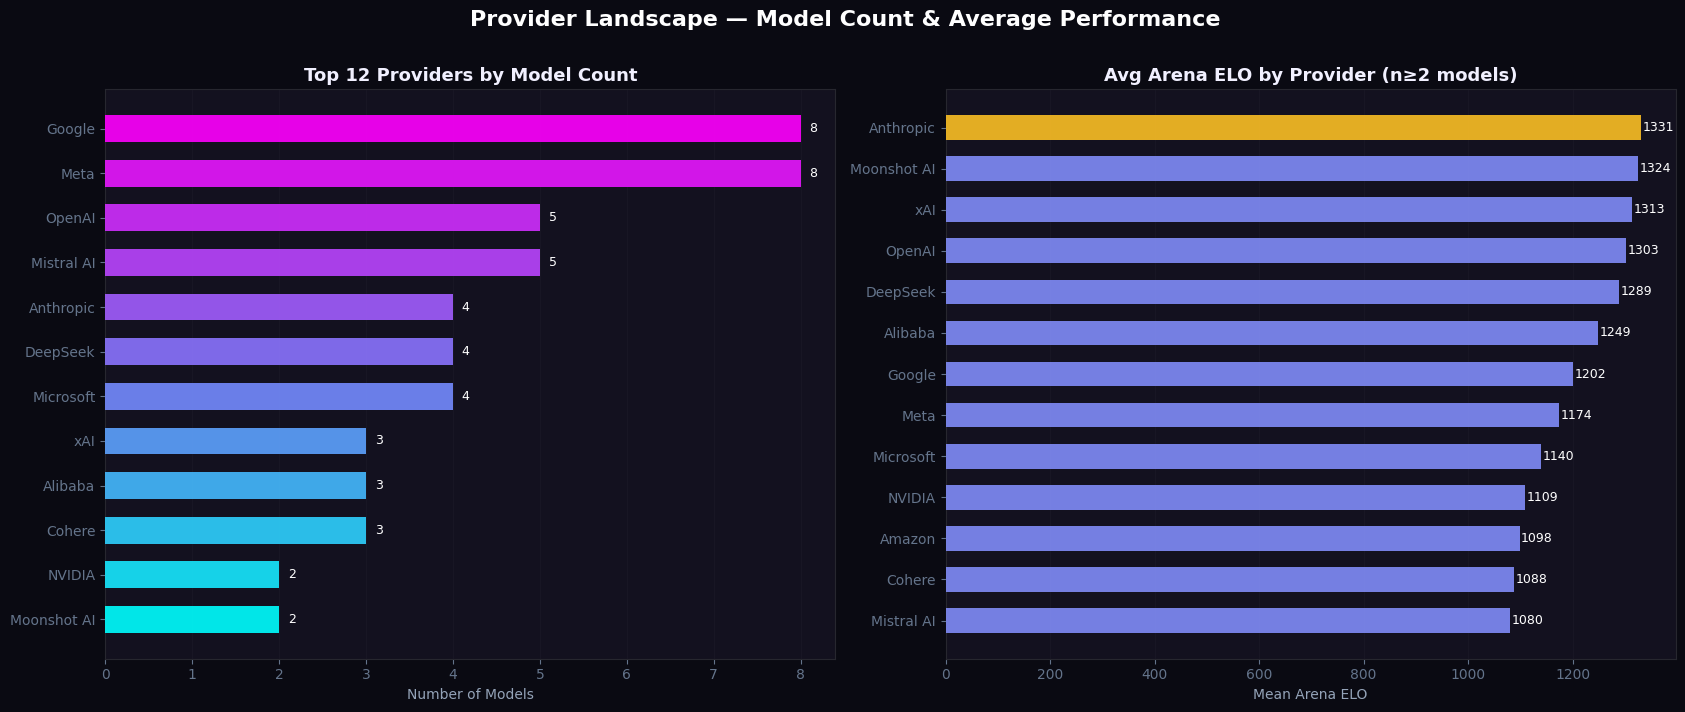

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Provider Landscape — Model Count & Average Performance', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Top providers by model count
ax = axes[0]
prov_counts = df['provider'].value_counts().head(12)
colors_p = [plt.cm.cool(i/11) for i in range(12)]
ax.barh(range(12), prov_counts.values[::-1], color=colors_p, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(12)); ax.set_yticklabels(prov_counts.index[::-1], fontsize=10)
ax.set_xlabel('Number of Models'); ax.set_title('Top 12 Providers by Model Count', fontweight='bold')
for i, v in enumerate(prov_counts.values[::-1]):
    ax.text(v+0.1, i, str(v), va='center', fontsize=9, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Avg Arena ELO by provider (min 2 models)
ax = axes[1]
prov_elo = df.groupby('provider')['arena_elo'].agg(['mean','count'])
prov_elo = prov_elo[prov_elo['count']>=2].sort_values('mean')
bar_cols = [GOLD if i==len(prov_elo)-1 else INDIGO for i in range(len(prov_elo))]
ax.barh(range(len(prov_elo)), prov_elo['mean'], color=bar_cols, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(len(prov_elo))); ax.set_yticklabels(prov_elo.index, fontsize=10)
ax.set_xlabel('Mean Arena ELO'); ax.set_title('Avg Arena ELO by Provider (n≥2 models)', fontweight='bold')
for i, v in enumerate(prov_elo['mean']):
    ax.text(v+3, i, f'{v:.0f}', va='center', fontsize=9, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('01_providers.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Feature Engineering <a id='3'></a>


In [5]:
# Composite capability score (mean of all 9 benchmarks)
bench_cols = ['mmlu_score','humaneval_score','math_score','gpqa_score','gsm8k_score',
              'hellaswag_score','arc_challenge_score','truthfulqa_score','mbpp_score']
df['composite_score'] = df[bench_cols].mean(axis=1)

# Value score: MMLU per dollar of input cost (only where cost > 0)
df['mmlu_per_dollar'] = np.where(df['cost_input_per_1m_usd'] > 0,
                                  df['mmlu_score'] / df['cost_input_per_1m_usd'], np.nan)

# Cost tier
df['cost_tier'] = pd.cut(df['cost_input_per_1m_usd'],
                          bins=[-0.01, 0.01, 1, 5, 20, 100],
                          labels=['Free/Self-Host','Budget (<$1)','Mid ($1-5)','Premium ($5-20)','Frontier ($20+)'])

# Years since release (for trend analysis)
df['release_year'] = df['release_date'].dt.year

print('Engineered: composite_score, mmlu_per_dollar, cost_tier, release_year')
print(df[['composite_score','mmlu_per_dollar']].describe().round(2))
print('\nCost tier distribution:')
print(df['cost_tier'].value_counts())


Engineered: composite_score, mmlu_per_dollar, cost_tier, release_year
       composite_score  mmlu_per_dollar
count            61.00            27.00
mean             77.82           214.42
std               9.47           330.02
min              57.34             1.19
25%              70.20            27.95
50%              78.28            40.60
75%              85.48           232.71
max              93.24          1255.00

Cost tier distribution:
cost_tier
Free/Self-Host     34
Mid ($1-5)         15
Budget (<$1)        9
Premium ($5-20)     2
Frontier ($20+)     1
Name: count, dtype: int64


## 4. Benchmark Leaderboards <a id='4'></a>


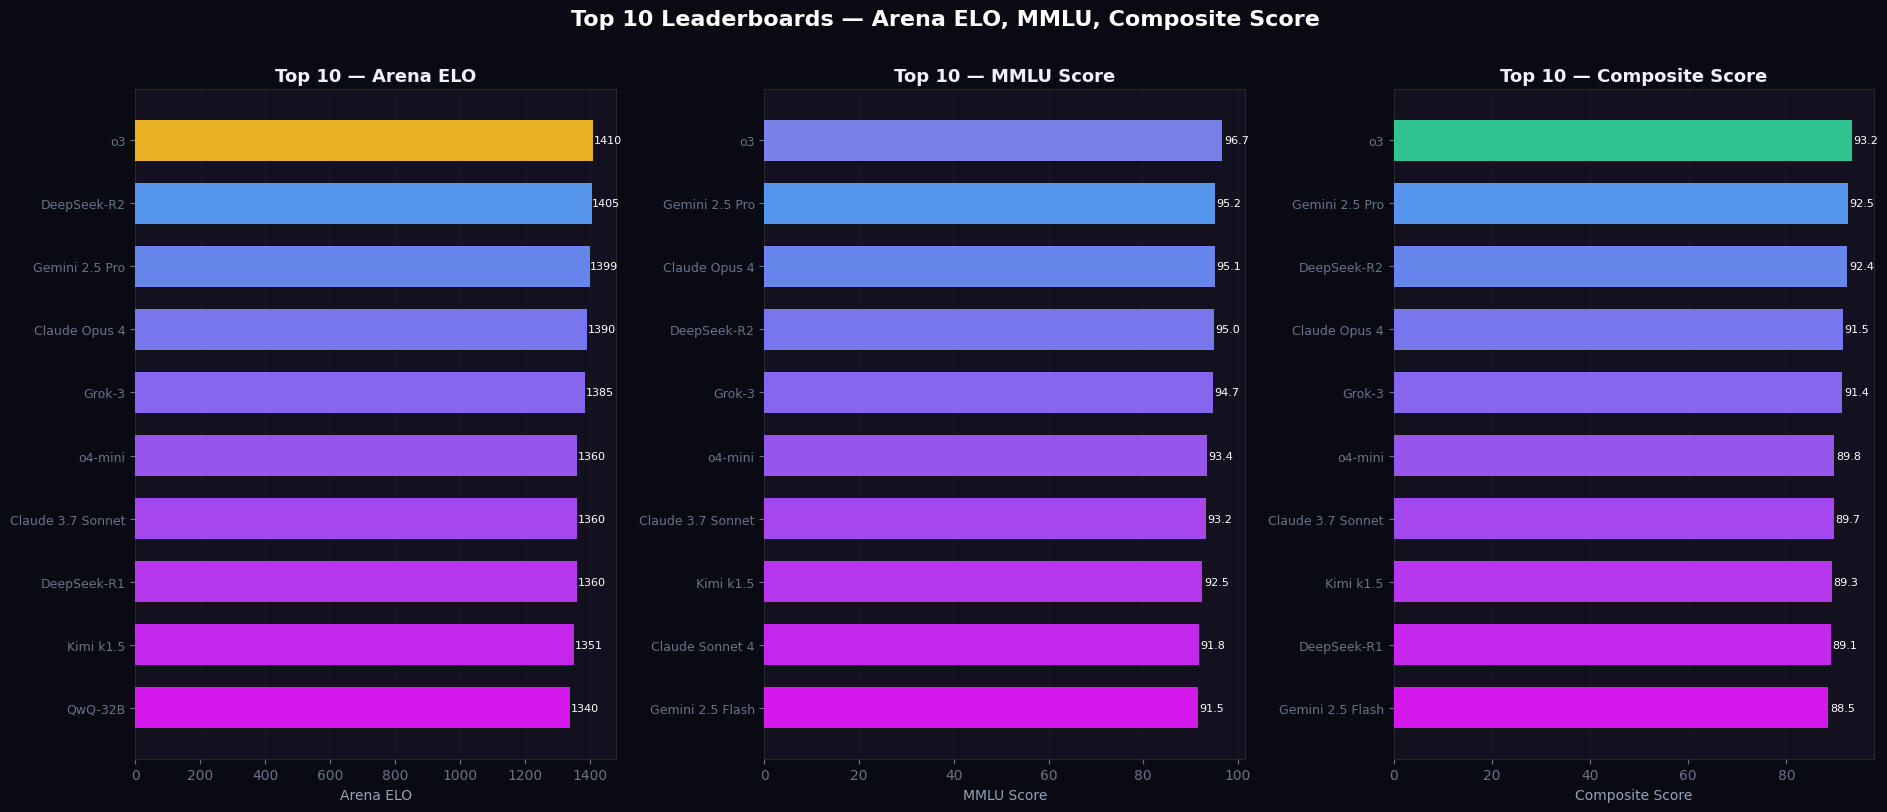

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Top 10 Leaderboards — Arena ELO, MMLU, Composite Score',
             fontsize=16, fontweight='bold', color='white', y=1.01)

for ax, col, label, cmap in zip(axes, ['arena_elo','mmlu_score','composite_score'],
                                  ['Arena ELO','MMLU Score','Composite Score'],
                                  [GOLD, INDIGO, GREEN]):
    top10 = df.nlargest(10, col)[['model_name','provider',col]]
    bar_cols = [cmap if i==0 else plt.cm.cool(0.3+0.6*i/9) for i in range(10)]
    ax.barh(range(10), top10[col].values[::-1], color=bar_cols[::-1], height=0.65, zorder=3, edgecolor='none', alpha=0.92)
    ax.set_yticks(range(10))
    ax.set_yticklabels([f"{n}" for n in top10['model_name'].values[::-1]], fontsize=9)
    ax.set_xlabel(label)
    ax.set_title(f'Top 10 — {label}', fontweight='bold')
    for i, v in enumerate(top10[col].values[::-1]):
        ax.text(v+(2 if col=='arena_elo' else 0.3), i, f'{v:.0f}' if col=='arena_elo' else f'{v:.1f}',
                va='center', fontsize=8, color='white')
    ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_leaderboards.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Reasoning Models — The Math Gap <a id='5'></a>


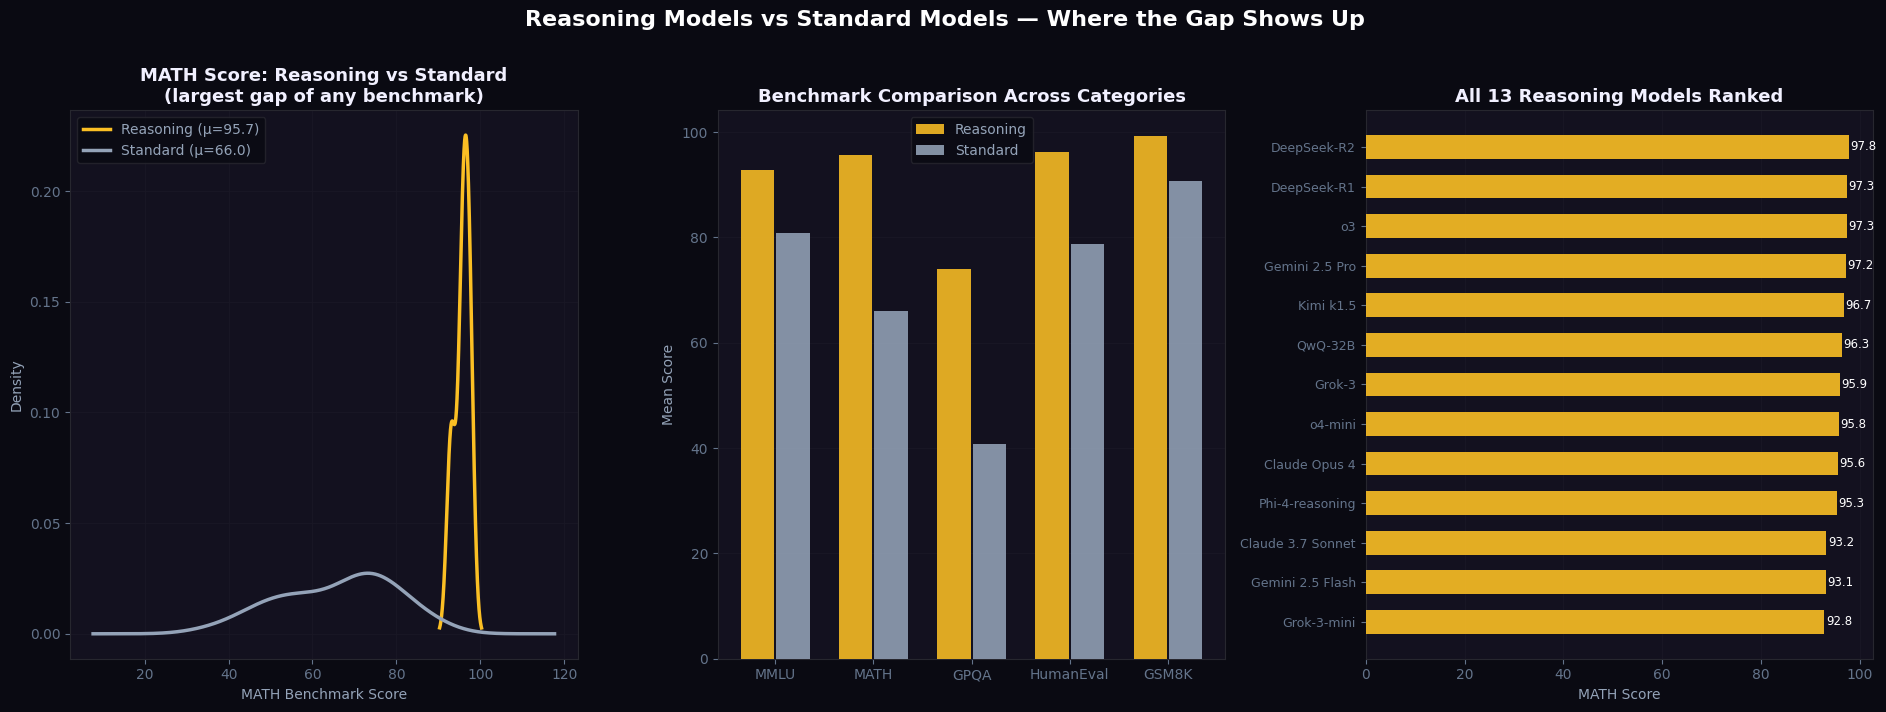

Reasoning vs Standard — full benchmark comparison:
  MMLU        : reasoning=92.8  standard=80.8  gap=+12.1
  MATH        : reasoning=95.7  standard=66.0  gap=+29.7
  GPQA        : reasoning=74.0  standard=40.8  gap=+33.2
  HumanEval   : reasoning=96.2  standard=78.8  gap=+17.4
  GSM8K       : reasoning=99.2  standard=90.8  gap=+8.4


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Reasoning Models vs Standard Models — Where the Gap Shows Up',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Math score KDE by reasoning flag
ax = axes[0]
for flag, color in REASON_PAL.items():
    sub = df[df['is_reasoning_model'].astype(str)==flag]['math_score']
    label = 'Reasoning' if flag=='True' else 'Standard'
    sub.plot.kde(ax=ax, color=color, lw=2.5, label=f'{label} (μ={sub.mean():.1f})')
ax.set_xlabel('MATH Benchmark Score'); ax.set_ylabel('Density')
ax.set_title('MATH Score: Reasoning vs Standard\n(largest gap of any benchmark)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, zorder=0)

# 2. Grouped bar: all benchmarks, reasoning vs standard
ax = axes[1]
bench_short = ['mmlu_score','math_score','gpqa_score','humaneval_score','gsm8k_score']
bench_labels = ['MMLU','MATH','GPQA','HumanEval','GSM8K']
x = np.arange(5)
reason_means = [df[df['is_reasoning_model'].astype(str)=='True'][c].mean() for c in bench_short]
std_means    = [df[df['is_reasoning_model'].astype(str)=='False'][c].mean() for c in bench_short]
ax.bar(x-0.18, reason_means, 0.34, color=GOLD, alpha=0.88, label='Reasoning', zorder=3)
ax.bar(x+0.18, std_means, 0.34, color=GRAY, alpha=0.88, label='Standard', zorder=3)
ax.set_xticks(x); ax.set_xticklabels(bench_labels, fontsize=10)
ax.set_ylabel('Mean Score')
ax.set_title('Benchmark Comparison Across Categories', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Reasoning models ranked by math score
ax = axes[2]
reasoning_models = df[df['is_reasoning_model'].astype(str)=='True'].nlargest(13,'math_score')
ax.barh(range(len(reasoning_models)), reasoning_models['math_score'].values[::-1],
        color=GOLD, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(len(reasoning_models)))
ax.set_yticklabels(reasoning_models['model_name'].values[::-1], fontsize=9)
ax.set_xlabel('MATH Score')
ax.set_title('All 13 Reasoning Models Ranked', fontweight='bold')
for i, v in enumerate(reasoning_models['math_score'].values[::-1]):
    ax.text(v+0.3, i, f'{v:.1f}', va='center', fontsize=8.5, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_reasoning.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Reasoning vs Standard — full benchmark comparison:')
for c, l in zip(bench_short, bench_labels):
    rm = df[df['is_reasoning_model'].astype(str)=='True'][c].mean()
    sm = df[df['is_reasoning_model'].astype(str)=='False'][c].mean()
    print(f'  {l:12s}: reasoning={rm:.1f}  standard={sm:.1f}  gap={rm-sm:+.1f}')


## 6. Open-Weight vs Proprietary <a id='6'></a>


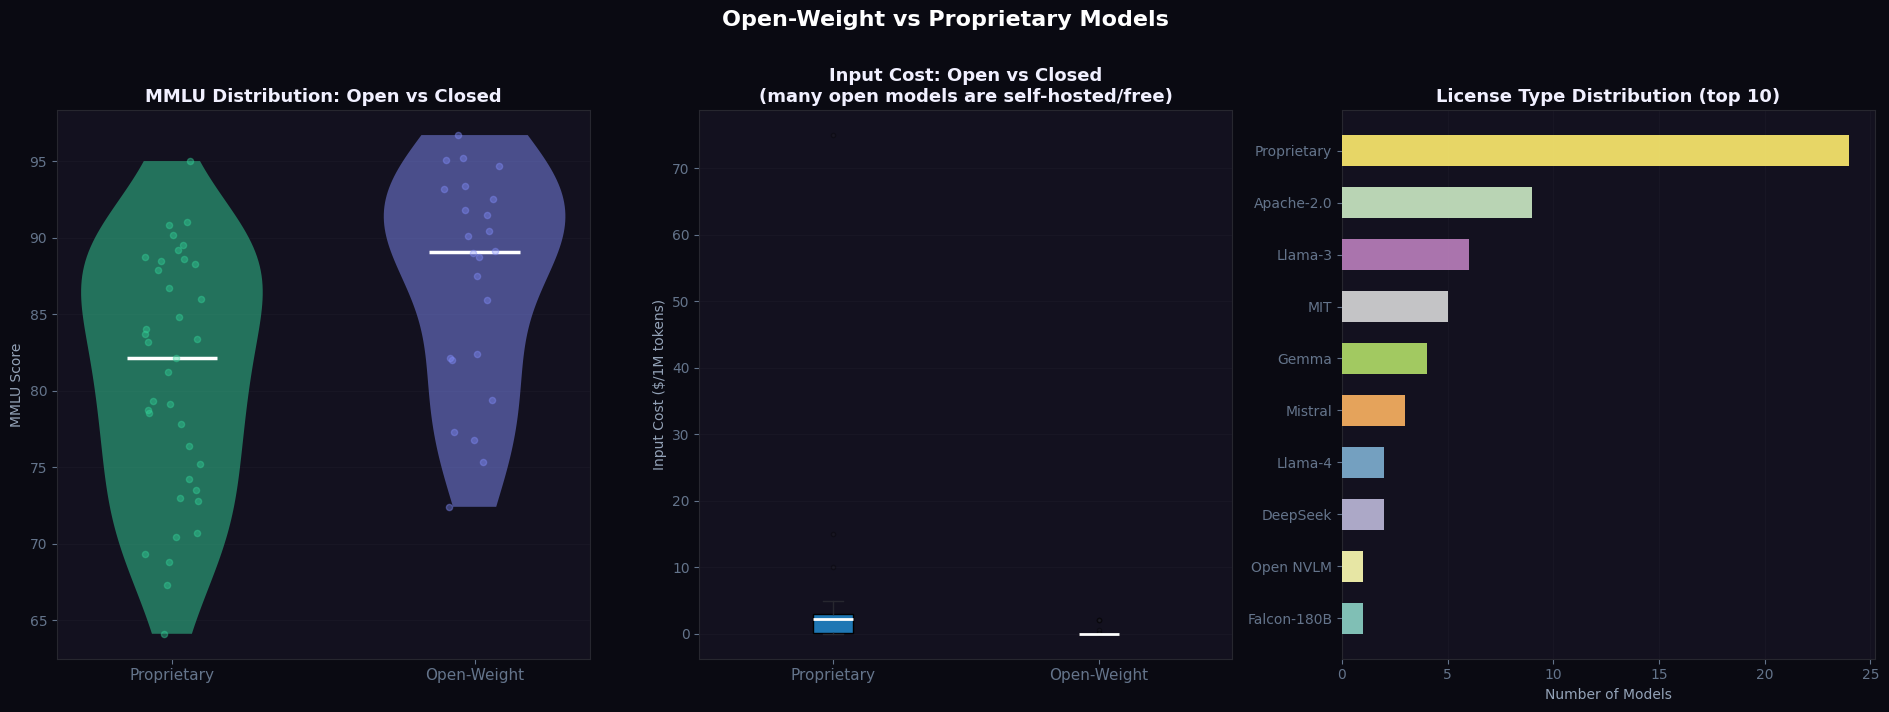

MMLU — Open-weight mean: 80.9
MMLU — Proprietary mean: 87.2


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Open-Weight vs Proprietary Models', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. MMLU violin
ax = axes[0]
for i, (flag, color) in enumerate(OPEN_PAL.items()):
    data = df[df['is_open_weight'].astype(str)==flag]['mmlu_score']
    vp = ax.violinplot(data, positions=[i], widths=0.6, showmedians=True, showextrema=False)
    for pc in vp['bodies']: pc.set_facecolor(color); pc.set_alpha(0.5)
    vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
    jit = np.random.uniform(-0.1,0.1,len(data))
    ax.scatter(i+jit, data, s=20, alpha=0.4, color=color, zorder=4)
ax.set_xticks([0,1]); ax.set_xticklabels(['Proprietary','Open-Weight'], fontsize=11)
ax.set_ylabel('MMLU Score')
ax.set_title('MMLU Distribution: Open vs Closed', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Cost comparison
ax = axes[1]
open_cost = df[df['is_open_weight'].astype(str)=='True']['cost_input_per_1m_usd']
closed_cost = df[df['is_open_weight'].astype(str)=='False']['cost_input_per_1m_usd']
ax.boxplot([closed_cost, open_cost], patch_artist=True,
           medianprops=dict(color='white', linewidth=2),
           whiskerprops=dict(color=GRID), capprops=dict(color=GRID),
           flierprops=dict(marker='o', markersize=3, markerfacecolor=GRID, alpha=0.3, linestyle='none'))
ax.set_xticklabels(['Proprietary','Open-Weight'], fontsize=11)
ax.set_ylabel('Input Cost ($/1M tokens)')
ax.set_title('Input Cost: Open vs Closed\n(many open models are self-hosted/free)', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. License type breakdown
ax = axes[2]
lic_counts = df['license_type'].value_counts().head(10)
colors_l = [plt.cm.Set3(i/9) for i in range(10)]
ax.barh(range(10), lic_counts.values[::-1], color=colors_l, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(10)); ax.set_yticklabels(lic_counts.index[::-1], fontsize=10)
ax.set_xlabel('Number of Models')
ax.set_title('License Type Distribution (top 10)', fontweight='bold')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_open_vs_closed.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'MMLU — Open-weight mean: {df[df["is_open_weight"].astype(str)=="True"]["mmlu_score"].mean():.1f}')
print(f'MMLU — Proprietary mean: {df[df["is_open_weight"].astype(str)=="False"]["mmlu_score"].mean():.1f}')


## 7. Cost vs Performance — Finding the Value Frontier <a id='7'></a>


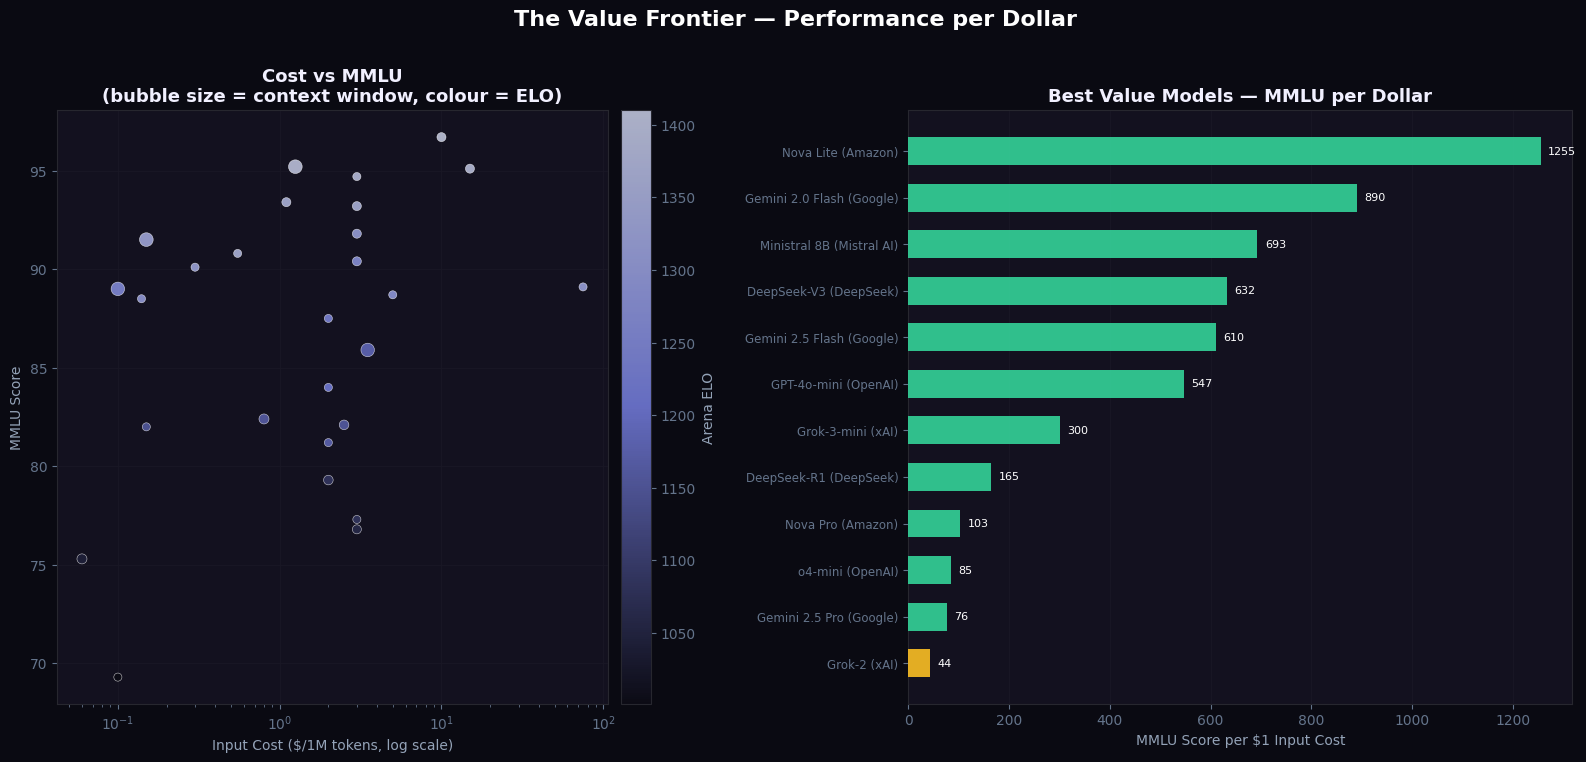

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor(BG)
fig.suptitle('The Value Frontier — Performance per Dollar', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Cost vs MMLU scatter, log-x, sized by context window
ax = axes[0]
paid = df[df['cost_input_per_1m_usd']>0]
sc = ax.scatter(paid['cost_input_per_1m_usd'], paid['mmlu_score'],
                s=np.sqrt(paid['context_window_k'])*3, c=paid['arena_elo'], cmap=CMAP_I,
                alpha=0.75, edgecolors='white', linewidths=0.4, zorder=3)
ax.set_xscale('log')
plt.colorbar(sc, ax=ax, label='Arena ELO', pad=0.02)
ax.set_xlabel('Input Cost ($/1M tokens, log scale)')
ax.set_ylabel('MMLU Score')
ax.set_title('Cost vs MMLU\n(bubble size = context window, colour = ELO)', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Best value models (MMLU per dollar) ranked
ax = axes[1]
top_value = df.dropna(subset=['mmlu_per_dollar']).nlargest(12, 'mmlu_per_dollar')
colors_v = [GOLD if i==0 else GREEN for i in range(12)]
ax.barh(range(12), top_value['mmlu_per_dollar'].values[::-1], color=colors_v, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(12))
ax.set_yticklabels([f"{n} ({p})" for n,p in zip(top_value['model_name'].values[::-1], top_value['provider'].values[::-1])], fontsize=8.5)
ax.set_xlabel('MMLU Score per $1 Input Cost')
ax.set_title('Best Value Models — MMLU per Dollar', fontweight='bold')
for i, v in enumerate(top_value['mmlu_per_dollar'].values[::-1]):
    ax.text(v+15, i, f'{v:.0f}', va='center', fontsize=8, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_value_frontier.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Context Window & Capability Trends <a id='8'></a>


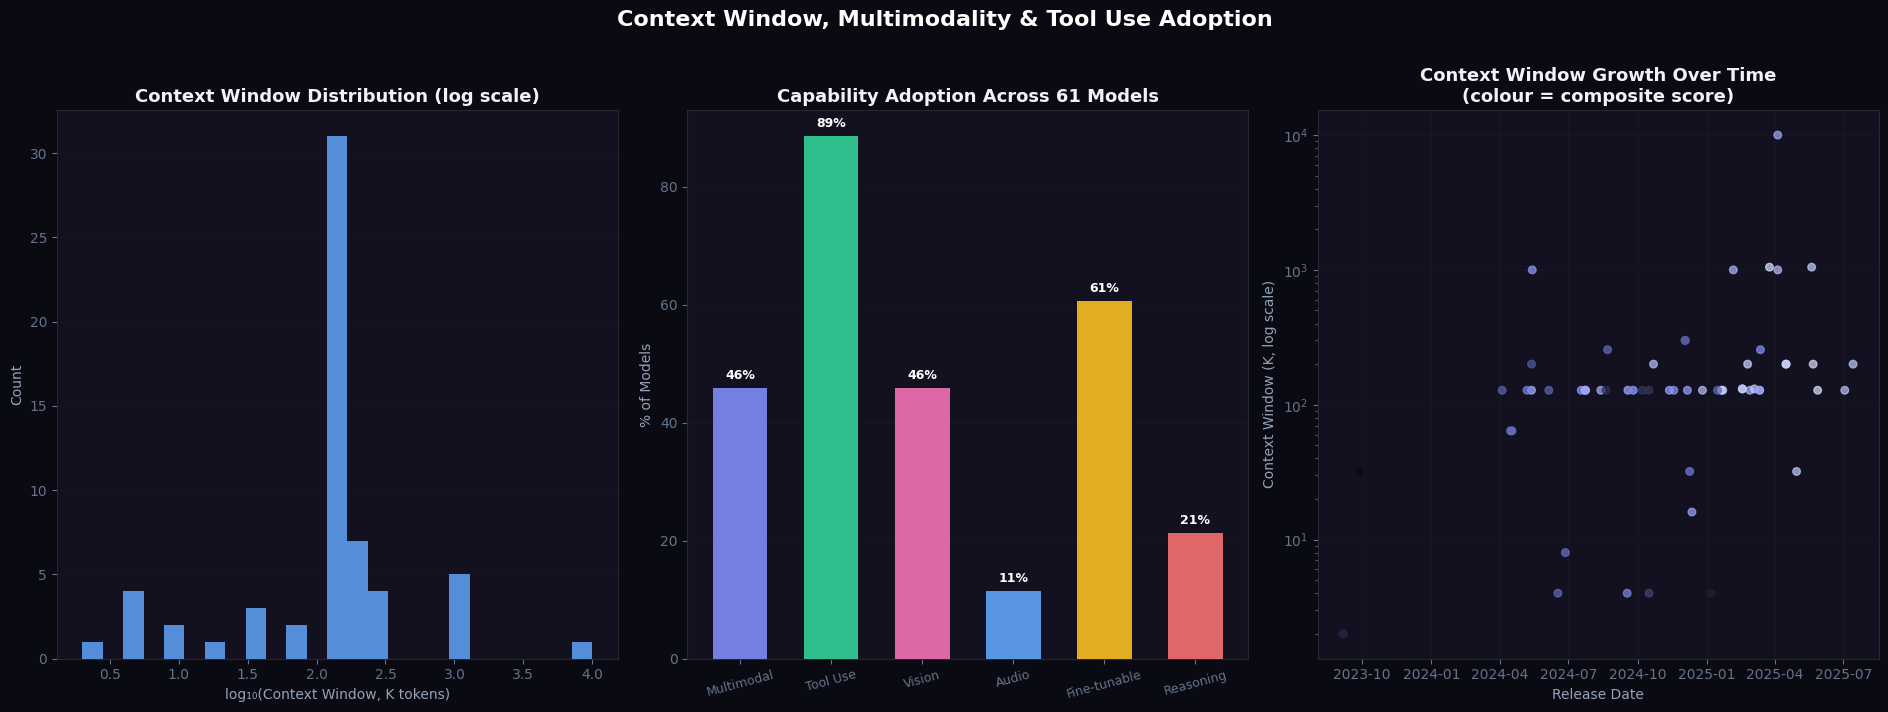

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Context Window, Multimodality & Tool Use Adoption', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Context window distribution (log)
ax = axes[0]
ax.hist(np.log10(df['context_window_k']), bins=25, color=BLUE, alpha=0.85, edgecolor='none', zorder=3)
ax.set_xlabel('log₁₀(Context Window, K tokens)')
ax.set_ylabel('Count')
ax.set_title('Context Window Distribution (log scale)', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Capability flags prevalence
ax = axes[1]
flags = ['is_multimodal','tool_use','vision','audio','fine_tunable','is_reasoning_model']
flag_labels = ['Multimodal','Tool Use','Vision','Audio','Fine-tunable','Reasoning']
pct = [(df[f].astype(str)=='True').mean()*100 for f in flags]
colors_f = [INDIGO, GREEN, PINK, BLUE, GOLD, RED]
bars = ax.bar(range(6), pct, color=colors_f, width=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_xticks(range(6)); ax.set_xticklabels(flag_labels, fontsize=9, rotation=15)
ax.set_ylabel('% of Models')
ax.set_title('Capability Adoption Across 61 Models', fontweight='bold')
for bar, v in zip(bars, pct):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Context window vs release date scatter
ax = axes[2]
ax.scatter(df['release_date'], df['context_window_k'], c=df['composite_score'], cmap=CMAP_I, s=30, alpha=0.7, zorder=3)
ax.set_yscale('log')
ax.set_xlabel('Release Date'); ax.set_ylabel('Context Window (K, log scale)')
ax.set_title('Context Window Growth Over Time\n(colour = composite score)', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('06_context_capability.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Benchmark Correlation Structure <a id='9'></a>


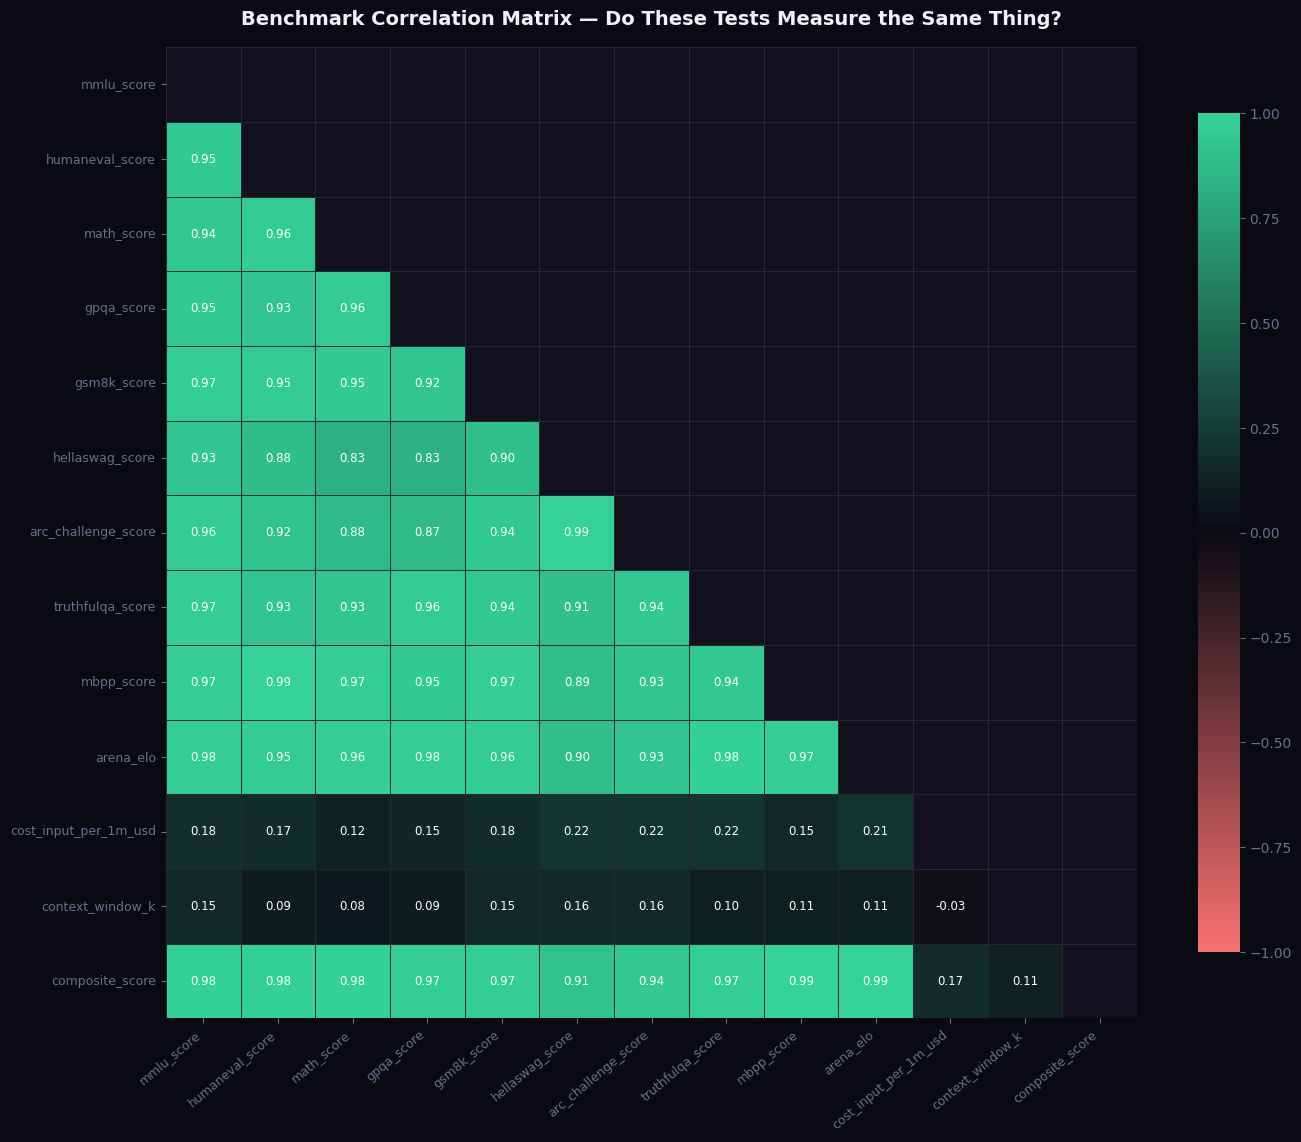

Top correlates with arena_elo:
composite_score          0.988
truthfulqa_score         0.977
gpqa_score               0.976
mmlu_score               0.976
mbpp_score               0.967
math_score               0.962
gsm8k_score              0.957
humaneval_score          0.954
arc_challenge_score      0.932
hellaswag_score          0.896
cost_input_per_1m_usd    0.214
context_window_k         0.107
Name: arena_elo, dtype: float64


In [11]:
corr_cols = bench_cols + ['arena_elo','cost_input_per_1m_usd','context_window_k','composite_score']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_DIV, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, linecolor=GRID,
            annot_kws={'size':8.5,'color':'white'}, cbar_kws={'shrink':0.78}, ax=ax, square=True)
ax.set_title('Benchmark Correlation Matrix — Do These Tests Measure the Same Thing?',
             fontsize=14, fontweight='bold', pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('07_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Top correlates with arena_elo:')
print(corr['arena_elo'].drop('arena_elo').sort_values(key=abs, ascending=False).round(3))


## 10. Release Timeline & Provider Trajectories <a id='10'></a>


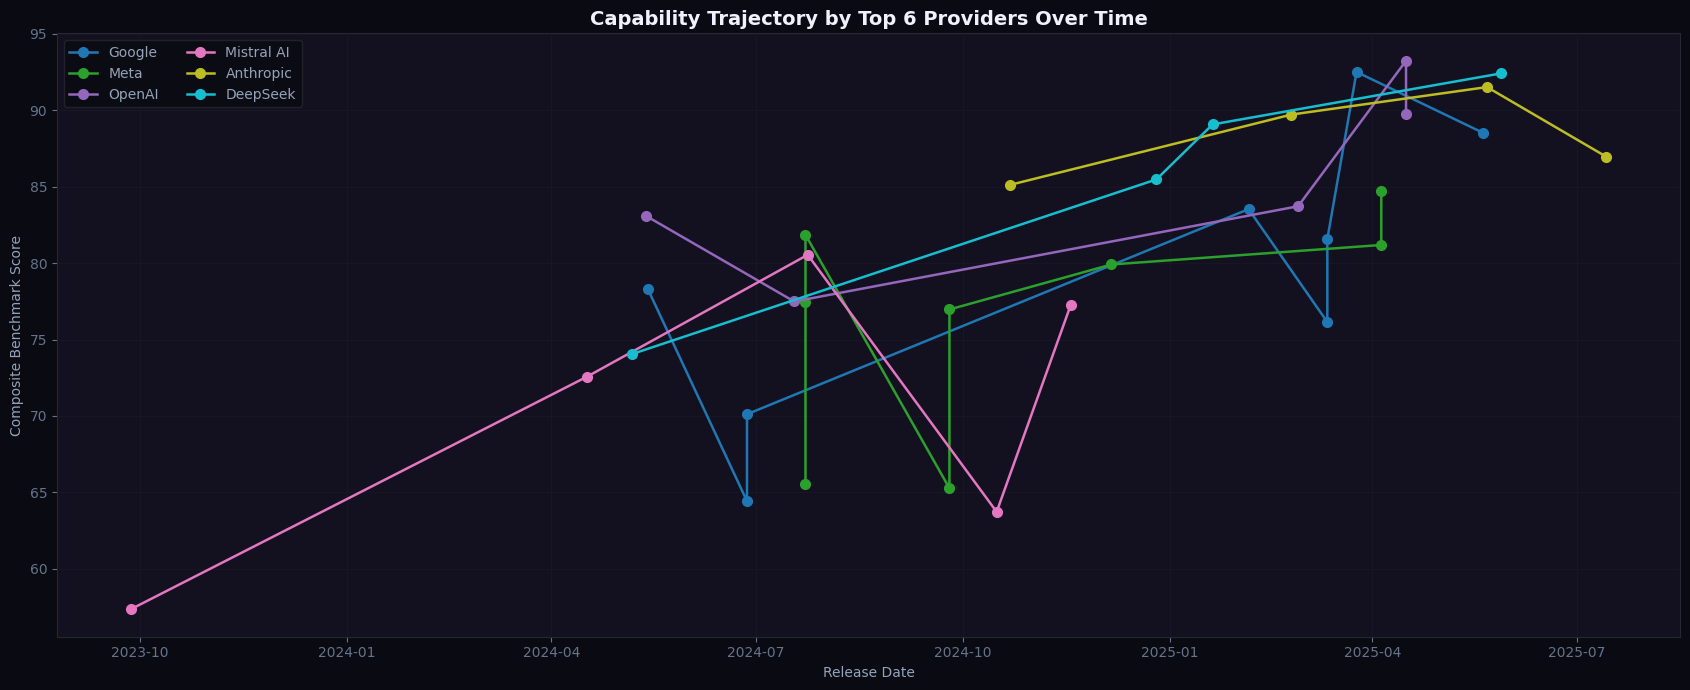

In [12]:
fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)

top_providers = df['provider'].value_counts().head(6).index.tolist()
prov_colors = plt.cm.tab10(np.linspace(0,1,6))
for prov, color in zip(top_providers, prov_colors):
    sub = df[df['provider']==prov].sort_values('release_date')
    ax.plot(sub['release_date'], sub['composite_score'], 'o-', color=color, lw=1.8, ms=7, label=prov, zorder=4)
ax.set_xlabel('Release Date'); ax.set_ylabel('Composite Benchmark Score')
ax.set_title('Capability Trajectory by Top 6 Providers Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2); ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('08_timeline.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 11. ML — Predicting Arena ELO from Benchmarks <a id='11'></a>


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

feat_cols = bench_cols + ['context_window_k','cost_input_per_1m_usd']
X = df[feat_cols].fillna(df[feat_cols].median())
y = df['arena_elo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=150, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results[name] = {'model':model, 'preds':preds, 'r2':r2, 'mae':mae}
    print(f'{name:20s}  R²={r2:.4f}  MAE={mae:.1f} ELO points')

print(f'\nNote: only n={len(df)} models — small-sample R² should be read with caution.')


Linear Regression     R²=0.9597  MAE=18.9 ELO points
Random Forest         R²=0.9918  MAE=8.3 ELO points
Gradient Boosting     R²=0.9837  MAE=13.5 ELO points

Note: only n=61 models — small-sample R² should be read with caution.


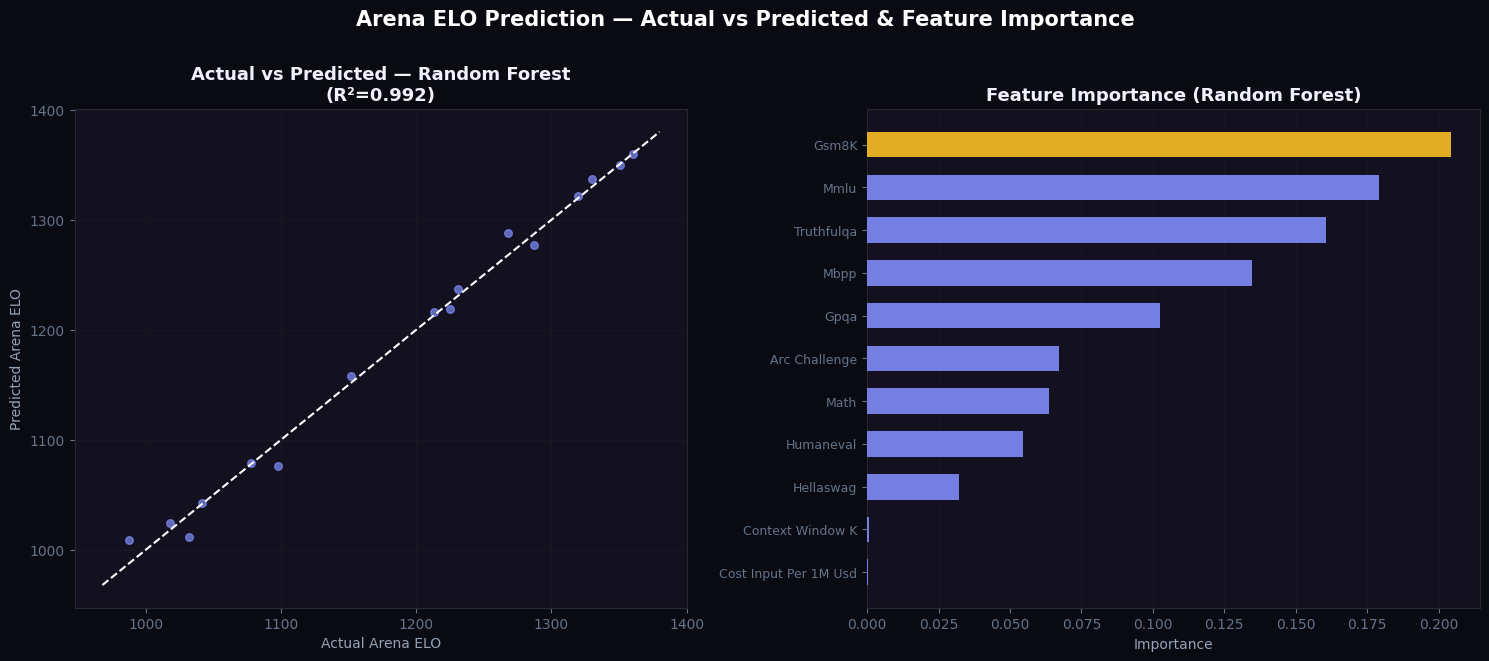

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Arena ELO Prediction — Actual vs Predicted & Feature Importance', fontsize=15, fontweight='bold', color='white', y=1.01)

best_name = max(results, key=lambda k: results[k]['r2'])
ax = axes[0]
ax.scatter(y_test, results[best_name]['preds'], color=INDIGO, s=30, alpha=0.7, zorder=3)
lim = [y_test.min()-20, y_test.max()+20]
ax.plot(lim, lim, color='white', lw=1.5, ls='--', zorder=5)
ax.set_xlabel('Actual Arena ELO'); ax.set_ylabel('Predicted Arena ELO')
ax.set_title(f'Actual vs Predicted — {best_name}\n(R²={results[best_name]["r2"]:.3f})', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

ax2 = axes[1]
rf = results['Random Forest']
imp = pd.Series(rf['model'].feature_importances_, index=feat_cols).sort_values()
colors_fi = [GOLD if v==imp.max() else INDIGO for v in imp.values]
ax2.barh(range(len(imp)), imp.values, color=colors_fi, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax2.set_yticks(range(len(imp))); ax2.set_yticklabels([f.replace('_score','').replace('_',' ').title() for f in imp.index], fontsize=9)
ax2.set_xlabel('Importance')
ax2.set_title('Feature Importance (Random Forest)', fontweight='bold')
ax2.grid(axis='x', zorder=0); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('09_ml_results.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 12. Key Takeaways <a id='12'></a>


<div style="background:#0a0a12;border-radius:14px;padding:30px 36px;font-family:'Segoe UI',sans-serif;border:1px solid #27272f;">

  <h2 style="color:#f1f0ff;margin-top:0;font-size:1.3rem;">🏆 Key Findings — LLM Benchmark Tracker 2026</h2>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:18px;">
    <div style="background:#13111f;border-radius:10px;padding:16px 18px;border-left:3px solid #fbbf24;">
      <div style="color:#fbbf24;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🧠 REASONING MODELS DOMINATE MATH</div>
      <p style="color:#94a3b8;margin:0;font-size:0.83rem;line-height:1.75;">The 13 reasoning models average <strong style='color:#fbfcfe'>95.7 on MATH</strong> vs just 66.0 for the 48
      standard models — a 29.7-point gap, by far the largest split in the dataset. The reasoning-model premium is
      far smaller on benchmarks like HellaSwag and ARC-Challenge, suggesting explicit reasoning chains pay off
      specifically on multi-step quantitative tasks, not general knowledge.</p>
    </div>
    <div style="background:#13111f;border-radius:10px;padding:16px 18px;border-left:3px solid #818cf8;">
      <div style="color:#818cf8;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">📊 BENCHMARKS ARE HIGHLY REDUNDANT</div>
      <p style="color:#94a3b8;margin:0;font-size:0.83rem;line-height:1.75;">MMLU correlates at <strong style='color:#fbfcfe'>r=0.95 with GPQA</strong>, r=0.95 with HumanEval, and r=0.98
      with Arena ELO — the human-judged leaderboard. This suggests a single latent "general capability" factor
      drives most observed variance, and running all 9 benchmarks may add less unique signal than it appears.</p>
    </div>
    <div style="background:#13111f;border-radius:10px;padding:16px 18px;border-left:3px solid #34d399;">
      <div style="color:#34d399;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">💰 BEST VALUE IS OPEN-WEIGHT</div>
      <p style="color:#94a3b8;margin:0;font-size:0.83rem;line-height:1.75;">Amazon Nova Lite delivers 75.3 MMLU at $0.06/1M tokens — the best raw MMLU-per-dollar in the dataset.
      Gemini 2.5 Flash and DeepSeek-V3 round out the value frontier with strong scores (88-91 MMLU) at under
      $0.15/1M. Frontier models like o3 cost over 80× more per token for roughly a 6-8 point MMLU gain.</p>
    </div>
    <div style="background:#13111f;border-radius:10px;padding:16px 18px;border-left:3px solid #f87171;">
      <div style="color:#f87171;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🔓 OPEN-WEIGHT GAP IS NARROWING BUT REAL</div>
      <p style="color:#94a3b8;margin:0;font-size:0.83rem;line-height:1.75;">Proprietary models average 87.2 MMLU vs 80.9 for open-weight — a 6.3-point gap. Meta and DeepSeek
      lead the open ecosystem; 34 of 61 models in this dataset have $0 input cost (self-hostable), making
      open-weight the dominant strategy by model count even though closed models still hold the top of the leaderboard.</p>
    </div>
    <div style="background:#13111f;border-radius:10px;padding:16px 18px;border-left:3px solid #f472b6;">
      <div style="color:#f472b6;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🏢 PROVIDER RANKINGS</div>
      <p style="color:#94a3b8;margin:0;font-size:0.83rem;line-height:1.75;">Anthropic posts the highest average Arena ELO (1331, n=4), narrowly ahead of Moonshot AI and xAI. OpenAI
      and DeepSeek follow closely. Among high-volume providers (8+ models), Google and Meta trail the
      top tier on average ELO despite shipping the most models — breadth over peak performance.</p>
    </div>
    <div style="background:#13111f;border-radius:10px;padding:16px 18px;border-left:3px solid #60a5fa;">
      <div style="color:#60a5fa;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🔧 TOOL USE IS NOW STANDARD</div>
      <p style="color:#94a3b8;margin:0;font-size:0.83rem;line-height:1.75;">89% of models in this tracker support tool/function calling — it's now table stakes, not a differentiator.
      Vision support sits at 46% and audio at just 11%, suggesting multimodality beyond text+images remains
      a frontier capability rather than a commodity feature.</p>
    </div>

  </div>

  <div style="background:#13111f;border-radius:10px;padding:14px 18px;border:1px solid #27272f;">
    <p style="margin:0;color:#64748b;font-size:0.78rem;line-height:1.6;">
      <strong style='color:#94a3b8;'>⚠️ Caveats:</strong> n=61 models is a small sample for regression — ELO prediction R² should be interpreted
      directionally, not as a precise forecasting tool. Arena ELO reflects human preference, which can diverge from
      static benchmark accuracy (style, safety behaviour, and verbosity all influence human ratings independent of
      raw capability). Pricing changes frequently in this market and may not reflect current rates.
    </p>
  </div>

  <div style="margin-top:14px;text-align:right;color:#27272f;font-size:0.72rem;">Author: Muhammad Aamir · 61 Models · 21 Providers · Kaggle Notebook</div>

</div>
